In [8]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch12.데이터 시각화</font>

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns

# from matplotlib import pyplot as plt
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'

# 한글 설정(Win/MacOS)
plt.style.use('default') # default -> 이셋팅은 반드시 한글 세팅 다음에 해줘야한다. 안그러면 한글 세팅이 없어진다. 
#plt.rc('font',family='Malgun Gothic')#윈도우즈 에서만 
#plt.rc('axes', unicode_minus=False)#축의 깨짐 방지

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# warning(경고) 안보이게 
import warnings 
warnings.filterwarnings(action='ignore') #경고메시지 안보이게
#warnings.filterwarnings(action='default') #기본 경고 메시지 다 보이게 

# 2절. Seaborn 
- matplotlib 기반으로 만든 고수준 그래픽 라이브러리 
    * 공식사이트 : https://seaborn.pydata.org/api.html
- Seaborn 으로 그래프를 그리기 위해서 다음의 단계를 따릅니다. 
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수를 이용해서 그래프 그리기(관계형-수치형, 범주형, 쌍관계, 밀도, 회귀, 다중그래프...) 
        - 그래프 커스터마이징
    4) 그래프를 출력 (show), 출력(savefig)

## 2.1데이터 준비하기
- iris, titanic

In [14]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [17]:
titanic = sns.load_dataset('titanic')
# Pclass 승객 클래스(1 = 1등석; 2 = 2등석; 3 = 3등석)
# sibsp 함께 승선한 형제, 자매, 배우자 수
# parch 함께 승선한 부모 자식 수
# embarked 승선한 항구 (C = Cherbourg; Q = Queenstown; S = Southampton)
# boat 침몰시 탑승한 구명보트 번호
# body 사망자인 경우 지정된 번호
# home.dest 고향/목적지
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 2.2 미적속성 설정 )style, context, palette, figsize...) 
### 1) 그래프 스타일 지정 
- 미적 속성 설정 후, 한글 설정을 다시 실행 
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우즈 
    plt.rcParams['axes.unicode_minus'] = False
    
    범례교안 20p: https://stackoverflow.com/questions/30490740/

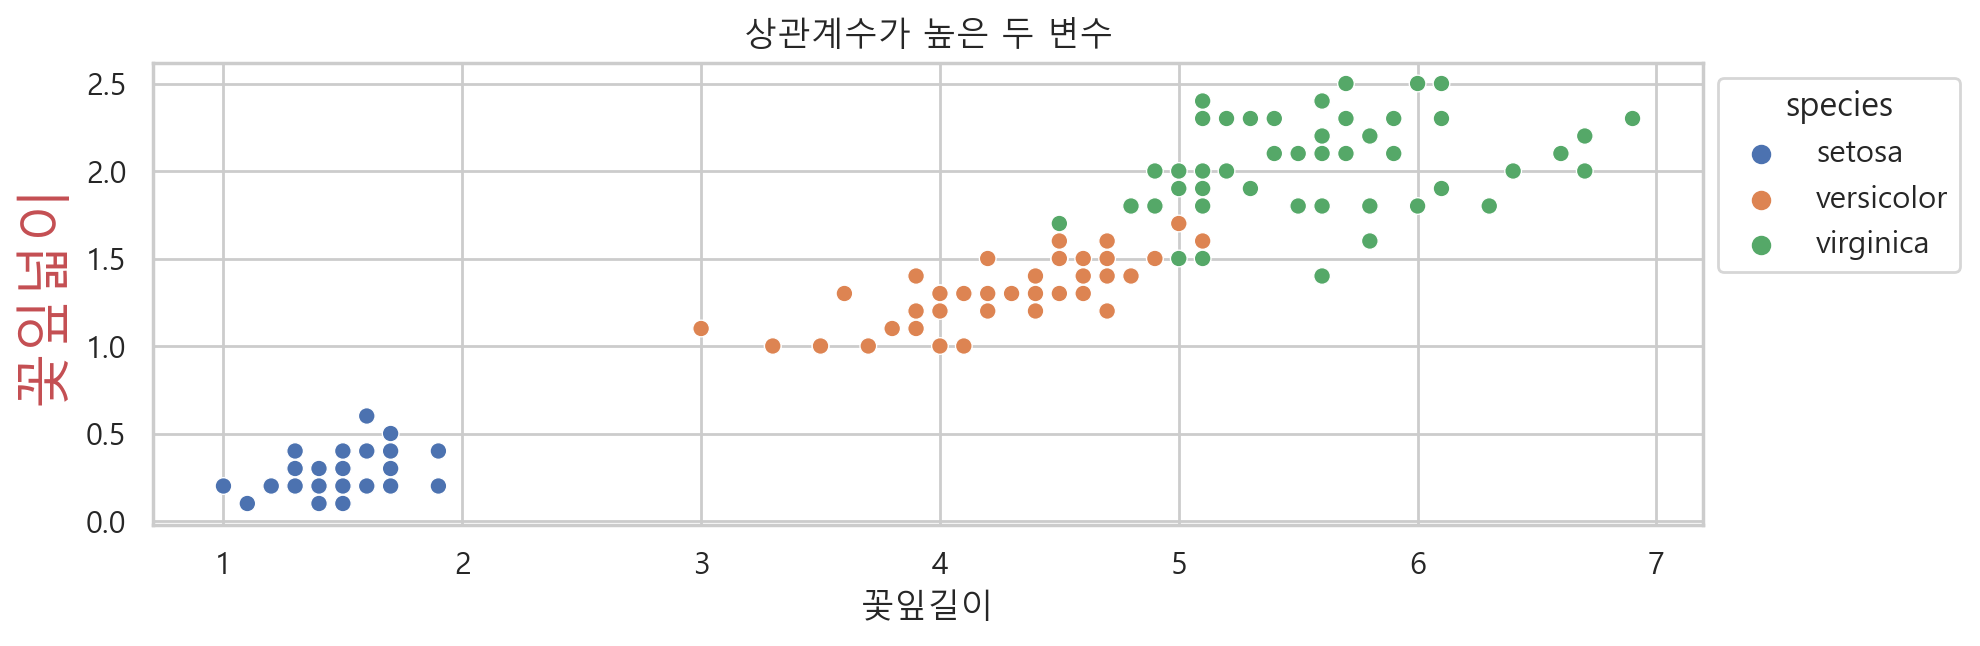

In [33]:
plt.rcParams['figure.figsize']= (10,3)
sns.set(style='whitegrid')# darkgrid, whitegrid, dark, white, ticks
#sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우즈 
plt.rcParams['axes.unicode_minus'] = False
ax= sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관계수가 높은 두 변수',
      xlabel='꽃잎길이')
xticks=[1,3,5,7]
ax.set_ylabel('꽃잎넓이', fontsize=20, color='r')
plt.show()

### 2) 컨텍스트 지정 (배율)

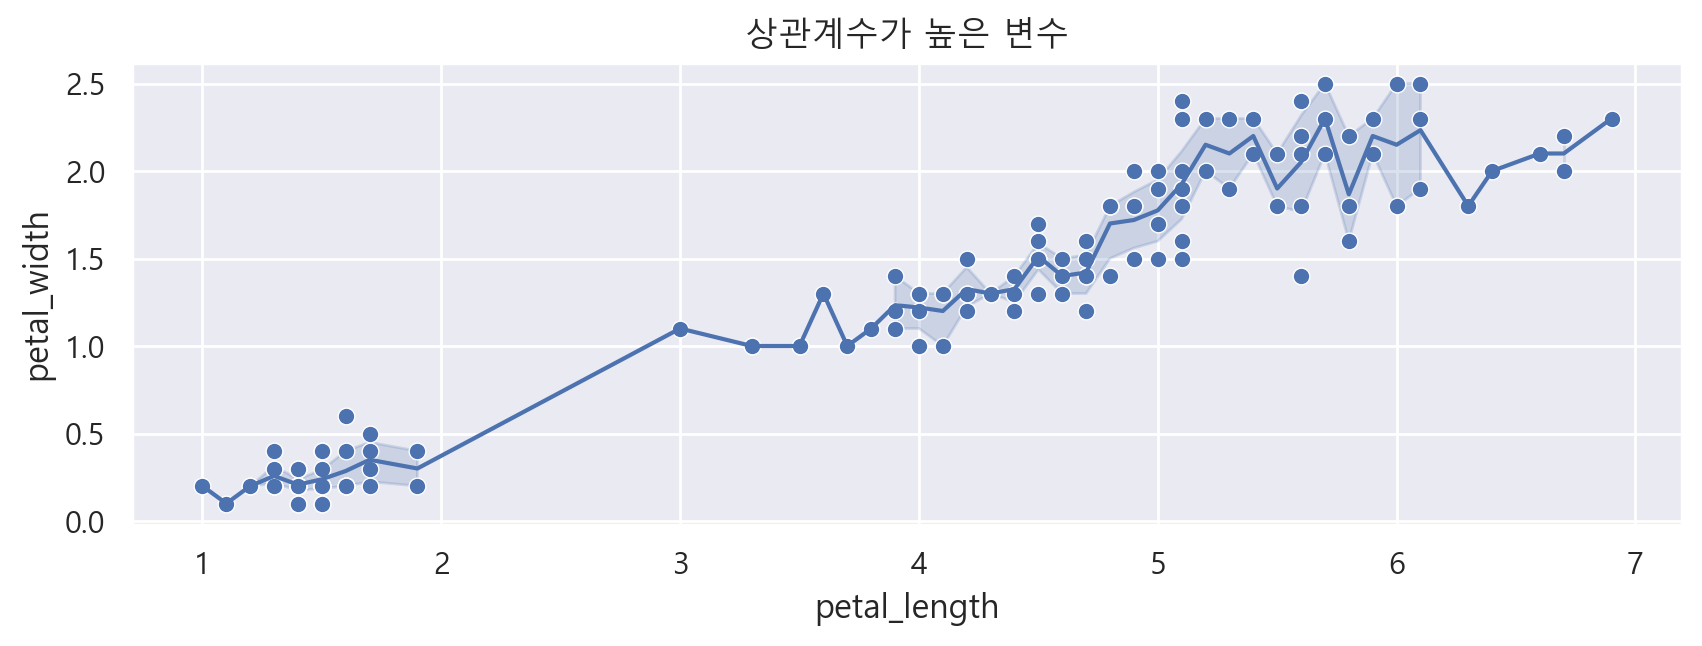

In [40]:
sns.set(context='notebook')#기본값이 notebook(1.0), paper(0.8), talk(1.3), poster(1.8)
#sns.set_context('notebook')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우즈 
plt.rcParams['axes.unicode_minus'] = False
sns.lineplot(data=iris, x='petal_length', y='petal_width')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')
plt.title('상관계수가 높은 변수')
plt.show()

### 3)컬러 팔레트

- https://matplotlib.org/stable/users/explain/colors/colormaps  (교안54p) 
- https://seaborn.pydata.org/tutorial/color_palettes.html   (교안54p) 
- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette  (교안54p) 

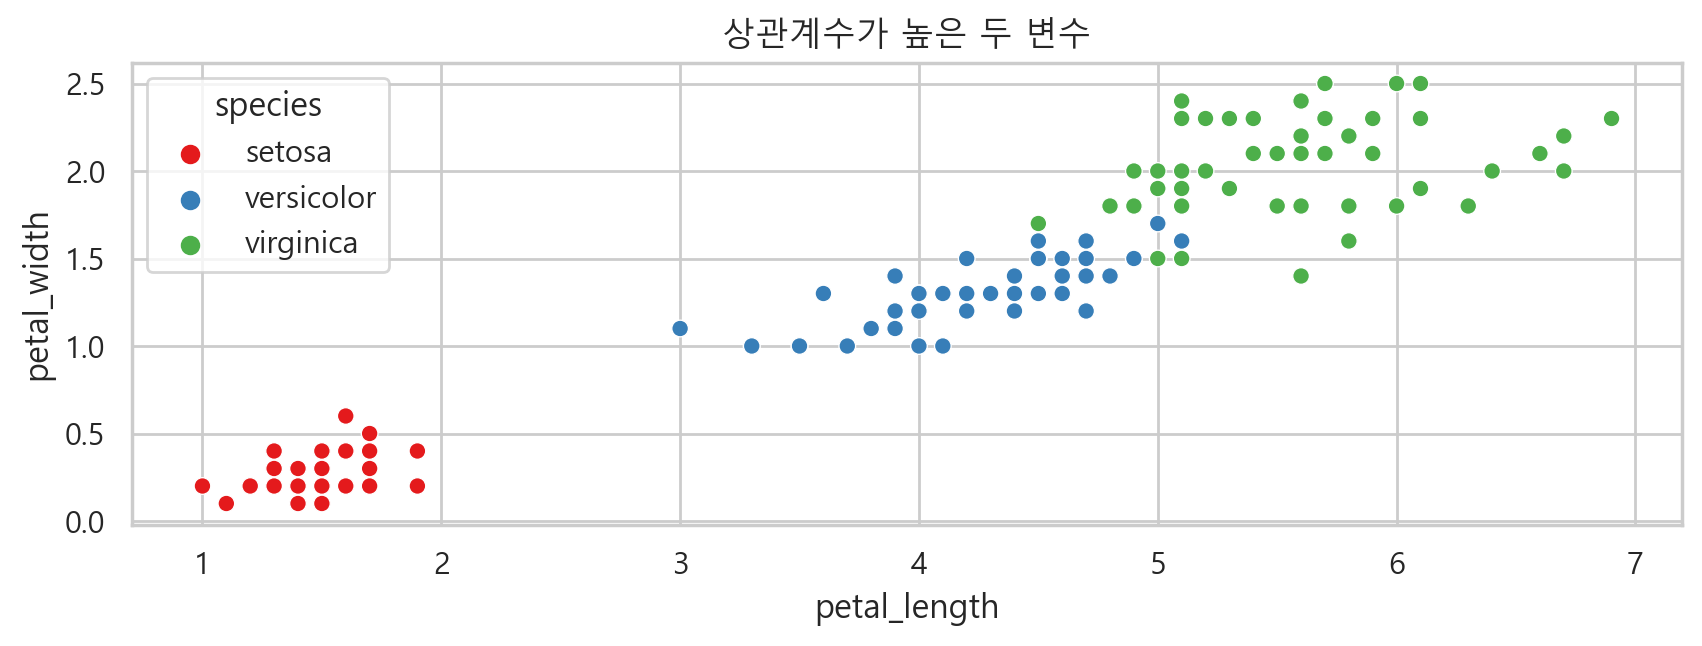

In [43]:
sns.set(palette='Set1', style='white', context='notebook')#기본미적 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우즈 
plt.rcParams['axes.unicode_minus'] = False
sns.set(style='whitegrid')# darkgrid, whitegrid, dark, white, ticks
#sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우즈 
plt.rcParams['axes.unicode_minus'] = False

ax= sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set1')

ax.set(title='상관계수가 높은 두 변수')
plt.show()

In [50]:
# from matplotlib import pyplot as plt
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt 
import seaborn as sns
#미적속성세팅 
sns.set(style='whitegrid', 
       context='notebook',
       palette='Set2',
       rc={'figure.figsize':(12,3)})
#한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
#warning 경고 안보이게 
import warnings 
warnings.filterwarnings(action='ignore') #경고메시지 안보이게
#warnings.filterwarnings(action='default') #기본 경고 메시지 다 보이게 

In [51]:
iris = sns.load_dataset('iris')
titanic=sns.load_dataset('titanic')

## 2.3 Seaborn 함수로 그래프 그리기 
### 1) 관계형 그래프 
    - scatterplot, lineplot, replot(서브플롯 제공)

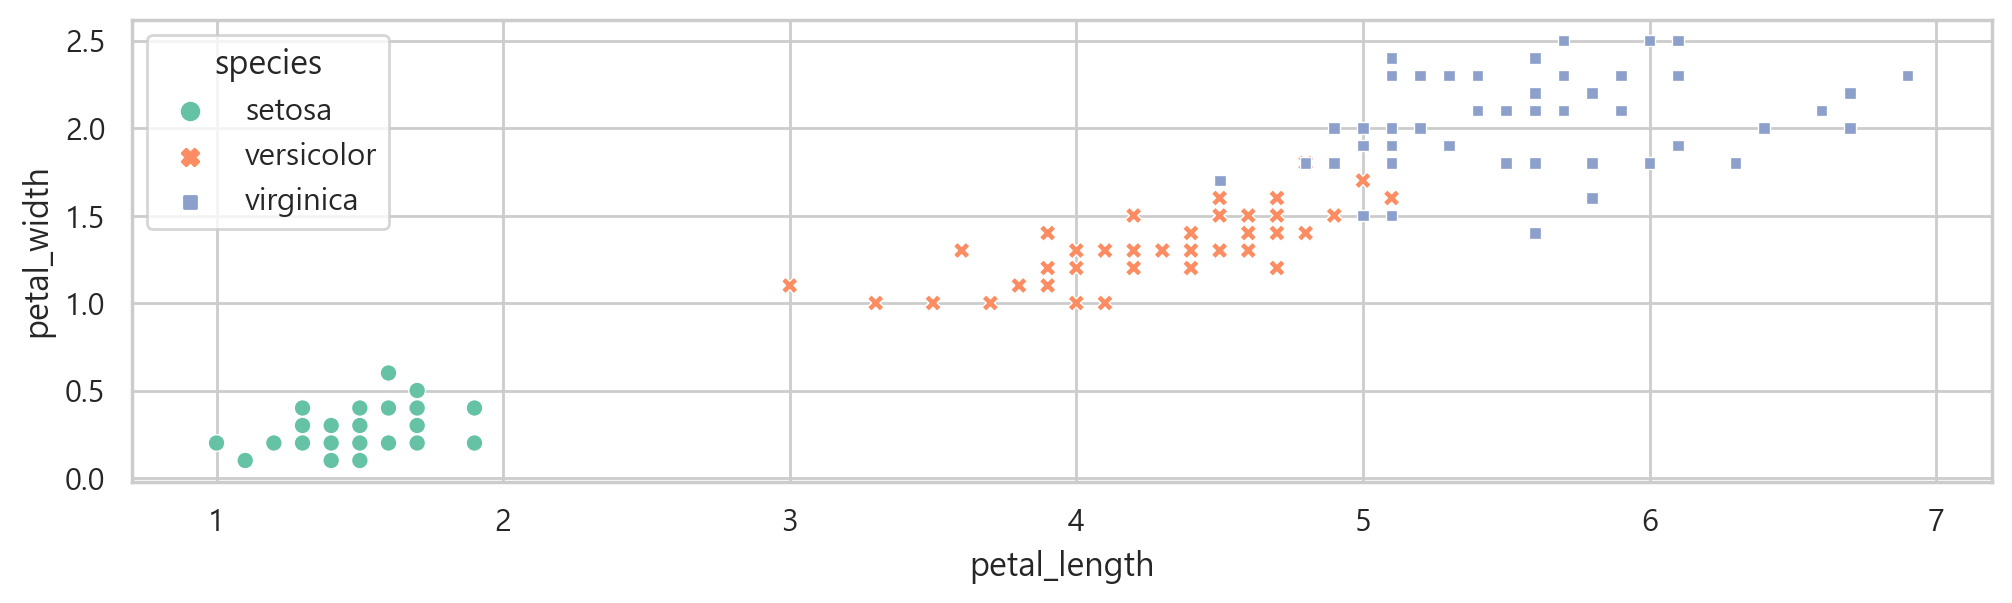

In [53]:
# 종별 다른 색상과 다른 스타일의 scatterplot
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', 
               style='species')
plt.show()

<Axes: xlabel='petal_width', ylabel='petal_length'>

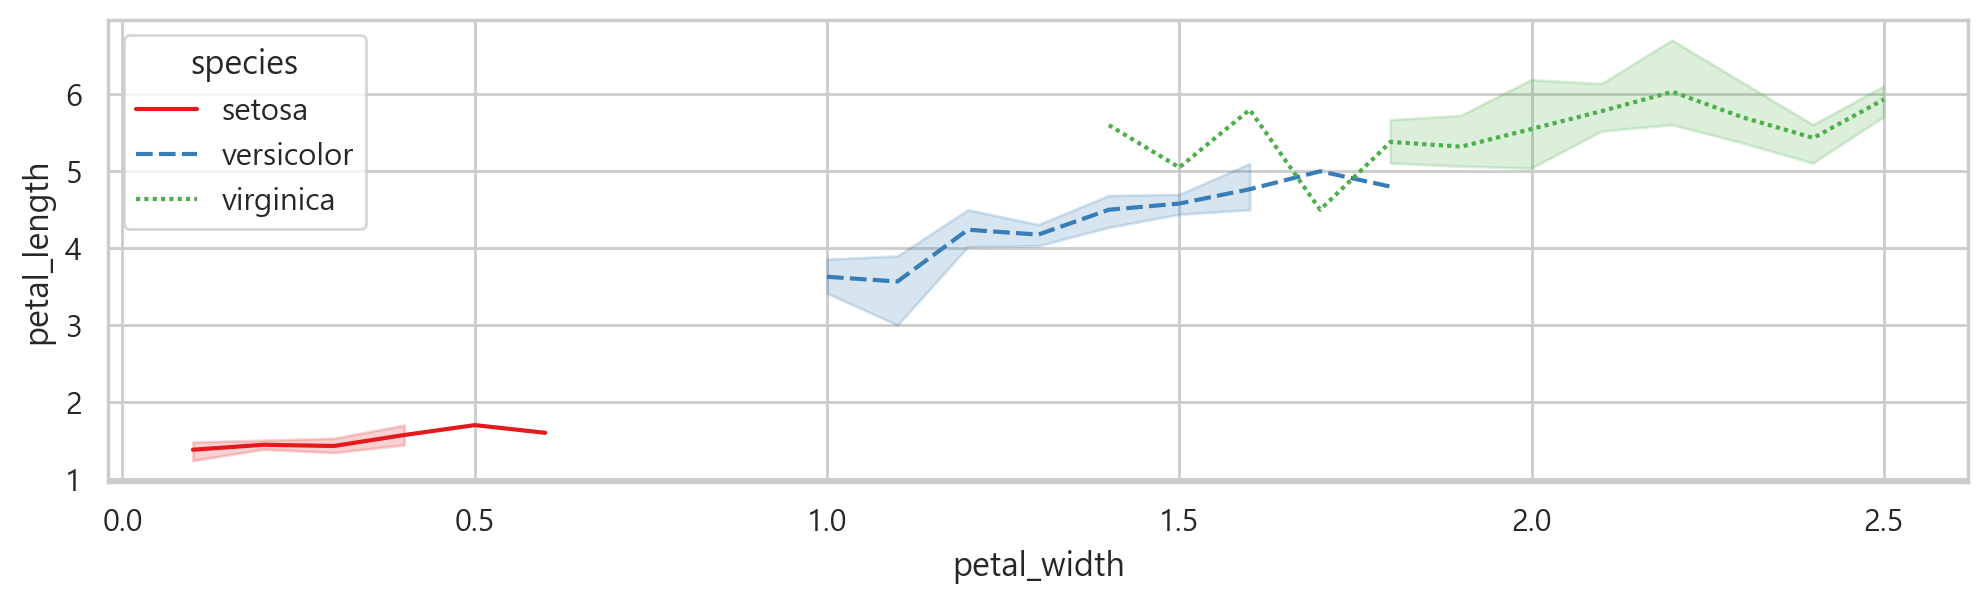

In [56]:
#종별 다른 색상과 다른 스타일이 lineplot 
sns.lineplot(data=iris, x='petal_width', y='petal_length', hue='species', style='species', palette='Set1')

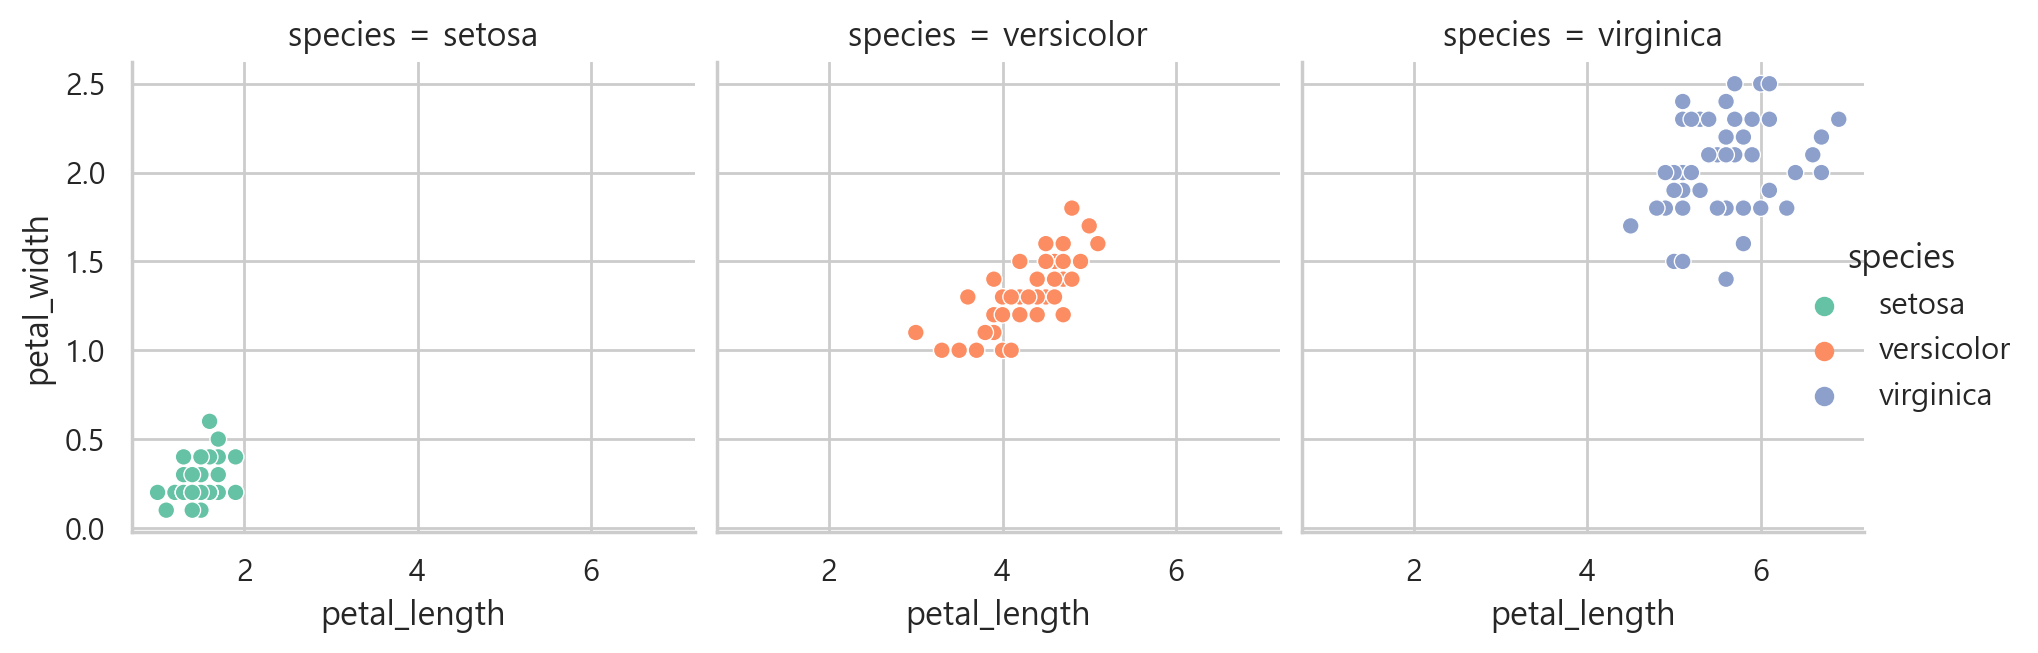

In [64]:
# 종별로 scatterplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수) 
g=sns.relplot(data=iris, x='petal_length', y='petal_width',hue='species',
          #kind='scatter', 
          col='species', # col 단위로 서브플롯 표현
          #col_wrap=2, #한줄에 표현될 서브플롯 수 
          #facet_kws={'sharey':False, 'sharex':False} #축공유여부 
           )
g.fig.set_size_inches(10,3)
plt.show()

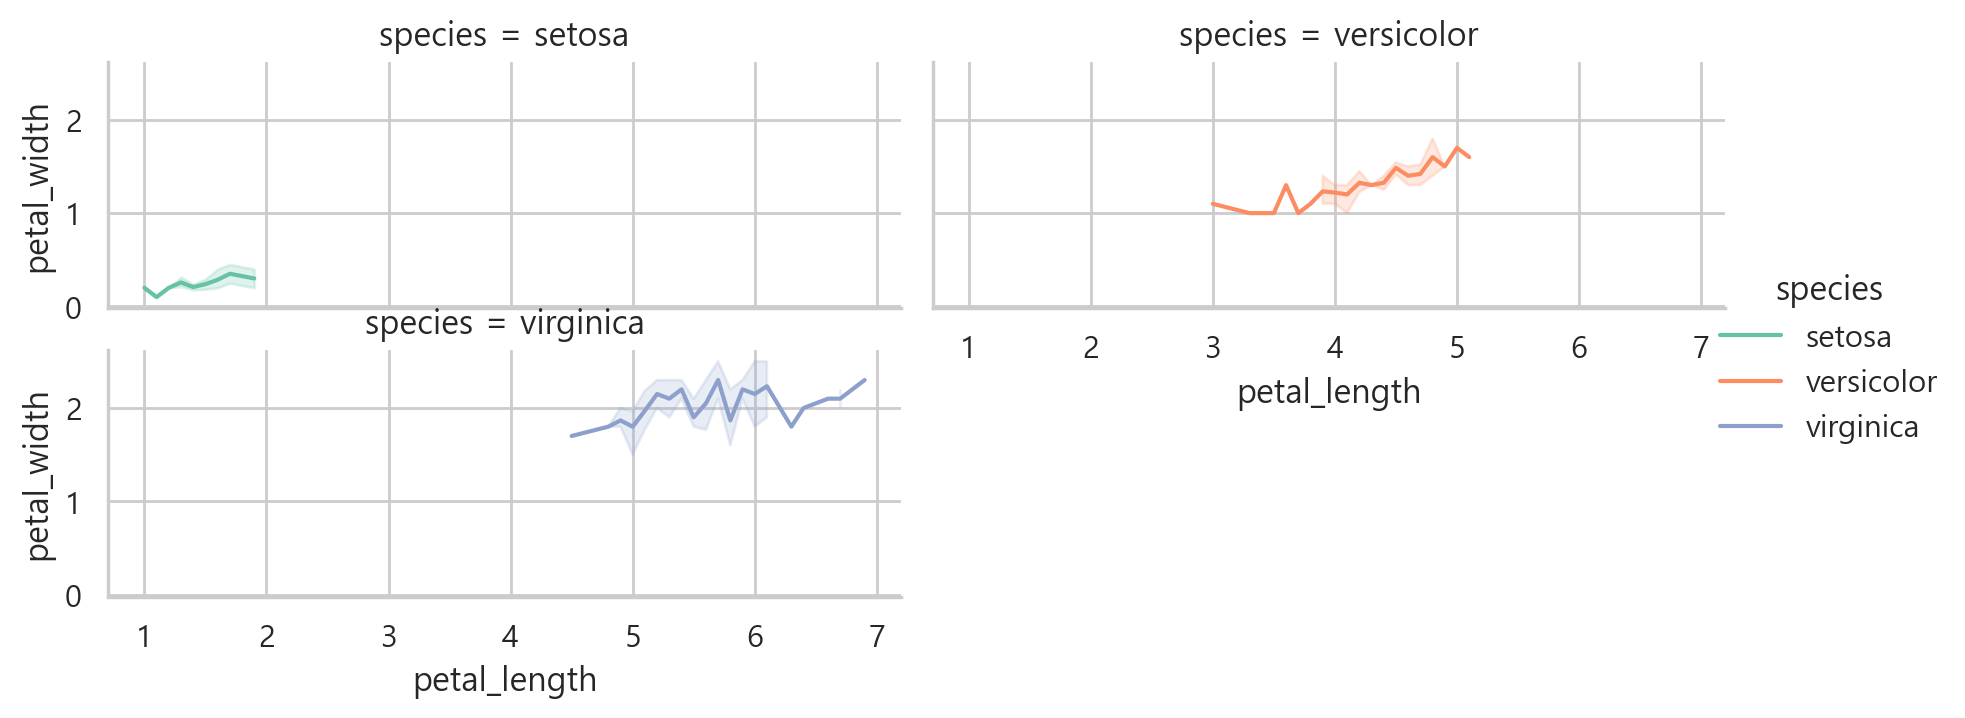

In [65]:
# 종별로 lineplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수) 
g=sns.relplot(data=iris, 
              x='petal_length', 
              y='petal_width',
              hue='species',
              kind='line', 
              col='species', # col 단위로 서브플롯 표현
              col_wrap=2, #한줄에 표현될 서브플롯 수 
              #facet_kws={'sharey':False, 'sharex':False} #축공유여부 
              )
g.fig.set_size_inches(10,3)
plt.show()

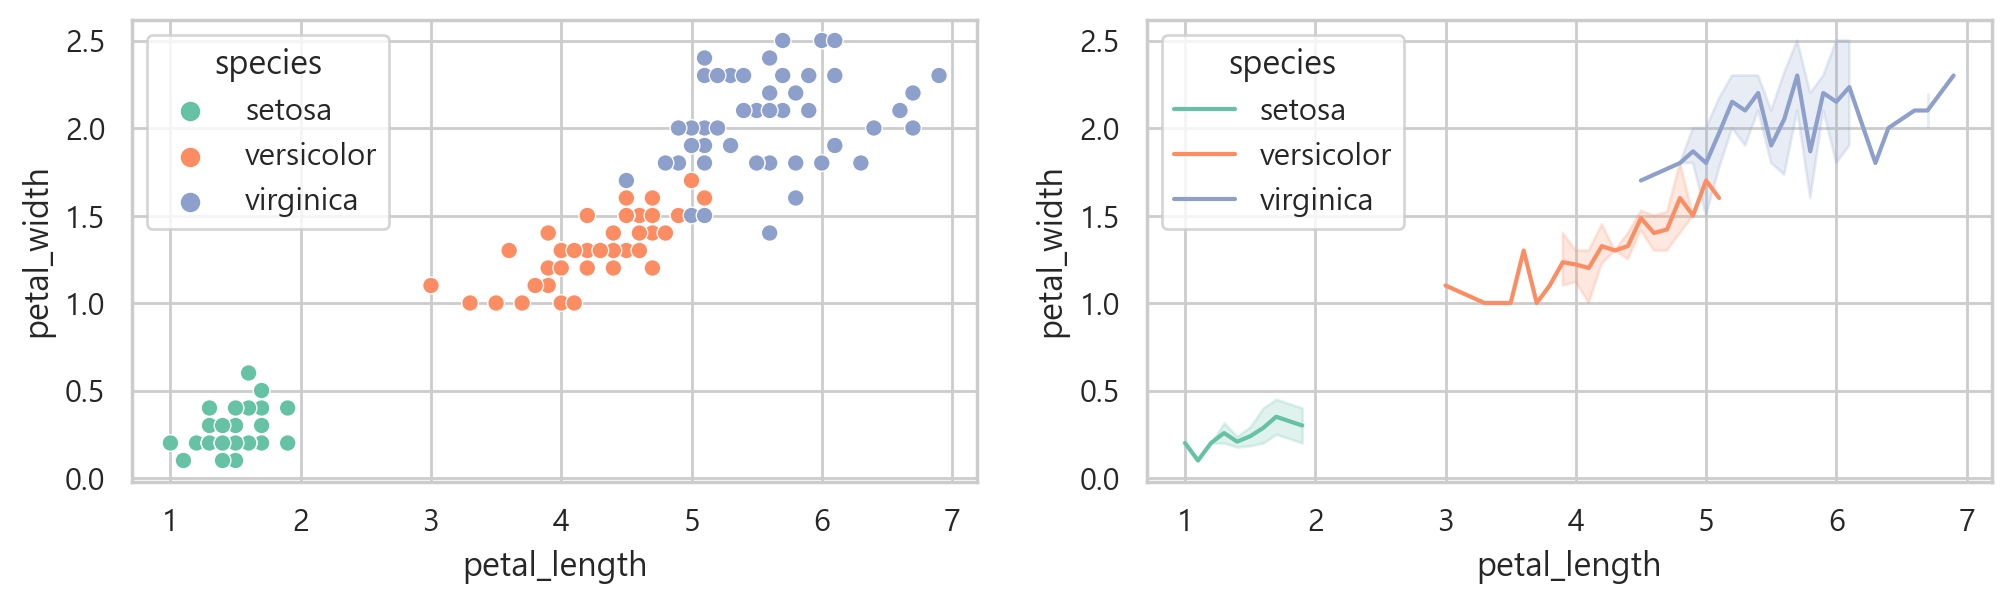

In [67]:
# 서브플롯: scatterplot, lineplot
fig, ax=plt.subplots(1,2)
#ax[0].scatter
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[0])
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[1])
plt.show()